In [70]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator

In [71]:
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=1.0) # Usually we would use different model for generating, evaluating and optimizing

In [72]:
class evaluationschema(BaseModel):
    evaluation: Literal['approved','needs_improvement'] = Field(description ="Evaluate the tweet")
    feedback: str= Field(description="Feedback for the tweet")

evaluation_model = model.with_structured_output(evaluationschema)

In [73]:
class TweeterState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved','needs_improvement']
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]


In [74]:
def generate(state:TweeterState):
    message = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
    Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

    Rules:
    - Do NOT use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple, day to day english
    """)]
    response = model.invoke(message).content
    return {"tweet": response, "tweet_history": [response]}

In [76]:
def evaluate(state:TweeterState):
    message =  [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    response = evaluation_model.invoke(message)
    return {"evaluation": response.evaluation, "feedback": response.feedback, "feedback_history": [response.feedback]}


In [77]:
def needs_improvement(state:TweeterState):
    message = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    response = model.invoke(message).content
    iteration = state['iteration'] + 1
    return {"tweet": response,"iteration": iteration, "tweet_history": [response]}

In [78]:
def check_evaluation(state: TweeterState):
    if state['evaluation'] == "approved" or state['max_iteration'] <= state['iteration']:
        return 'approved'
    else:
        return "needs_improvement"

In [79]:
graph = StateGraph(TweeterState)

graph.add_node('generate', generate)
graph.add_node('evaluate', evaluate)
graph.add_node('needs_improvement', needs_improvement)

graph.add_edge(START, 'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate', check_evaluation, {'approved': END, 'needs_improvement': 'needs_improvement'})
graph.add_edge('needs_improvement', 'evaluate')

workflow = graph.compile()

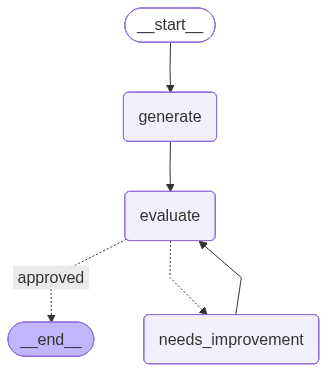

In [80]:
workflow

In [81]:
initial_state = {
    "topic": "hgvfthxct",
    "iteration":1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [82]:
print(result)

{'topic': 'hgvfthxct', 'tweet': 'My brain attempting to recall the meaning of "hgvfthxct" is a direct parallel to my frantic search for keys when I\'m already running late. Pure chaos. Send caffeine & a psychic. 🤯🔑 #BrainFart #SendHelp', 'evaluation': 'approved', 'feedback': "The tweet is relatable and humorous, comparing the struggle to recall a nonsensical word with the common panic of losing keys. The use of emojis and relevant hashtags enhances its appeal. It's concise, under the character limit, and avoids the auto-reject criteria. The humor lands well, and the sentiment is likely to resonate with many, giving it good potential for retweets.", 'iteration': 2, 'max_iteration': 5, 'tweet_history': ['My brain trying to remember what "hgvfthxct" means is basically me trying to remember where I put my keys when I\'m already late. Send help. And maybe a decoder ring. 🔑😂 #WhatIsThis #BrainMelt', 'My brain attempting to recall the meaning of "hgvfthxct" is a direct parallel to my frantic 

In [83]:
result

{'topic': 'hgvfthxct',
 'tweet': 'My brain attempting to recall the meaning of "hgvfthxct" is a direct parallel to my frantic search for keys when I\'m already running late. Pure chaos. Send caffeine & a psychic. 🤯🔑 #BrainFart #SendHelp',
 'evaluation': 'approved',
 'feedback': "The tweet is relatable and humorous, comparing the struggle to recall a nonsensical word with the common panic of losing keys. The use of emojis and relevant hashtags enhances its appeal. It's concise, under the character limit, and avoids the auto-reject criteria. The humor lands well, and the sentiment is likely to resonate with many, giving it good potential for retweets.",
 'iteration': 2,
 'max_iteration': 5,
 'tweet_history': ['My brain trying to remember what "hgvfthxct" means is basically me trying to remember where I put my keys when I\'m already late. Send help. And maybe a decoder ring. 🔑😂 #WhatIsThis #BrainMelt',
  'My brain attempting to recall the meaning of "hgvfthxct" is a direct parallel to my 